In [1]:
import gzip
import shutil
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
with gzip.open("roadNet-CA.txt.gz", 'rb') as f_in:
    with open("roadNet-CA.txt", 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

load dataset

In [4]:
df = pd.read_csv("roadNet-CA.txt", delim_whitespace=True, comment="#", header=None)

# Assign column names
df.columns = ["source", "target"]

print("\nDataset Preview:")
print(df.head())

print("\nDataset Shape:", df.shape)

/tmp/ipykernel_590/3025907754.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("roadNet-CA.txt", delim_whitespace=True, comment="#", header=None)



Dataset Preview:
   source  target
0       0       1
1       0       2
2       0     469
3       1       0
4       1       6

Dataset Shape: (5533214, 2)


size reduce

In [6]:
df_small = df.head(1000)

print("\nUsing subset of size:", len(df_small))


# Create Two Subgraphs

df1 = df_small.head(500)
df2 = df_small.tail(500)

G1 = nx.from_pandas_edgelist(df1, "source", "target")
G2 = nx.from_pandas_edgelist(df2, "source", "target")

print("\nSubgraph 1 - Nodes:", G1.number_of_nodes(), "Edges:", G1.number_of_edges())
print("Subgraph 2 - Nodes:", G2.number_of_nodes(), "Edges:", G2.number_of_edges())


Using subset of size: 1000

Subgraph 1 - Nodes: 265 Edges: 312
Subgraph 2 - Nodes: 251 Edges: 314


Visualize BEFORE LPA

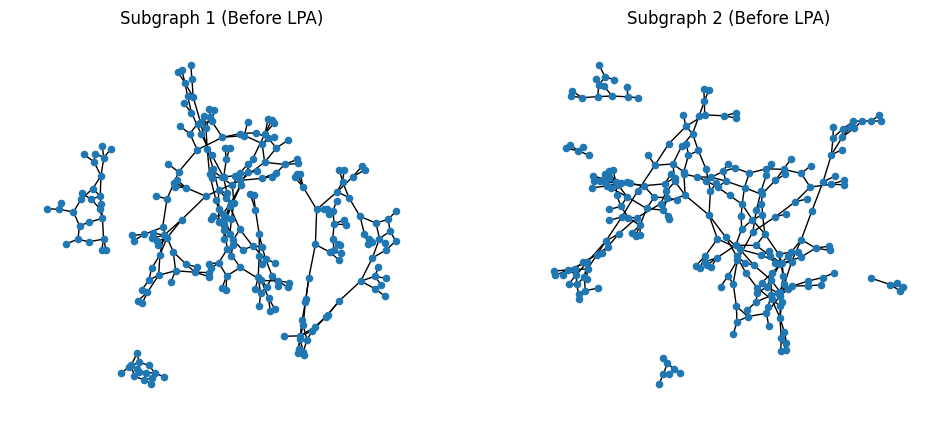

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
pos1 = nx.spring_layout(G1, seed=42)
nx.draw(G1, pos1, node_size=20)
plt.title("Subgraph 1 (Before LPA)")

plt.subplot(1,2,2)
pos2 = nx.spring_layout(G2, seed=42)
nx.draw(G2, pos2, node_size=20)
plt.title("Subgraph 2 (Before LPA)")

plt.show()

Apply LPA

In [8]:
from networkx.algorithms.community import label_propagation_communities

# Subgraph 1
comm1 = list(label_propagation_communities(G1))
map1 = {}
for i, c in enumerate(comm1):
    for node in c:
        map1[node] = i

# Subgraph 2
comm2 = list(label_propagation_communities(G2))
map2 = {}
for i, c in enumerate(comm2):
    for node in c:
        map2[node] = i

print("\nCommunities detected (Subgraph 1):", len(comm1))
print("Communities detected (Subgraph 2):", len(comm2))


Communities detected (Subgraph 1): 71
Communities detected (Subgraph 2): 72


Visualize AFTER LPA

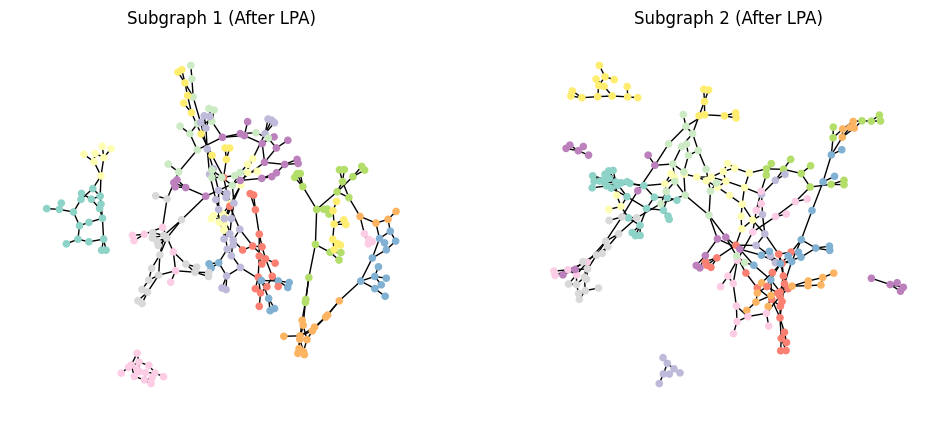

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
colors1 = [map1[n] for n in G1.nodes()]
nx.draw(G1, pos1, node_color=colors1, node_size=20, cmap=plt.cm.Set3)
plt.title("Subgraph 1 (After LPA)")

plt.subplot(1,2,2)
colors2 = [map2[n] for n in G2.nodes()]
nx.draw(G2, pos2, node_color=colors2, node_size=20, cmap=plt.cm.Set3)
plt.title("Subgraph 2 (After LPA)")

plt.show()

In [10]:
print("\n--- Subgraph 1 Communities ---")
for i, c in enumerate(comm1):
    print(f"Community {i}: Size = {len(c)}")

print("\n--- Subgraph 2 Communities ---")
for i, c in enumerate(comm2):
    print(f"Community {i}: Size = {len(c)}")


--- Subgraph 1 Communities ---
Community 0: Size = 3
Community 1: Size = 4
Community 2: Size = 6
Community 3: Size = 2
Community 4: Size = 3
Community 5: Size = 2
Community 6: Size = 4
Community 7: Size = 3
Community 8: Size = 2
Community 9: Size = 3
Community 10: Size = 6
Community 11: Size = 3
Community 12: Size = 4
Community 13: Size = 5
Community 14: Size = 4
Community 15: Size = 10
Community 16: Size = 4
Community 17: Size = 3
Community 18: Size = 2
Community 19: Size = 5
Community 20: Size = 3
Community 21: Size = 3
Community 22: Size = 3
Community 23: Size = 4
Community 24: Size = 4
Community 25: Size = 3
Community 26: Size = 3
Community 27: Size = 4
Community 28: Size = 7
Community 29: Size = 2
Community 30: Size = 4
Community 31: Size = 4
Community 32: Size = 4
Community 33: Size = 2
Community 34: Size = 5
Community 35: Size = 3
Community 36: Size = 4
Community 37: Size = 5
Community 38: Size = 5
Community 39: Size = 3
Community 40: Size = 3
Community 41: Size = 4
Community 4